In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

In [4]:
data = pd.read_csv("sample_data/tf_regression_dataset.csv")

In [5]:
data.head()

,x,y
0,77,79.775152
1,21,23.177279
2,22,25.609262
3,20,17.857388
4,36,41.849864


In [6]:
data.shape

(300, 2)

In [7]:
x = data['x']
y = data['y']

In [8]:
x

,x
0,77
1,21
2,22
3,20
4,36
...,...
295,71
296,46
297,55
298,62


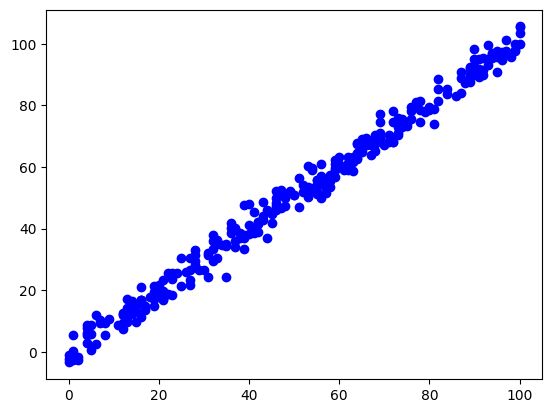

In [9]:
plt.scatter(x, y,c='b')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [11]:
x_train

,x
232,88
59,57
6,62
185,4
173,56
...,...
188,27
71,13
106,1
270,55


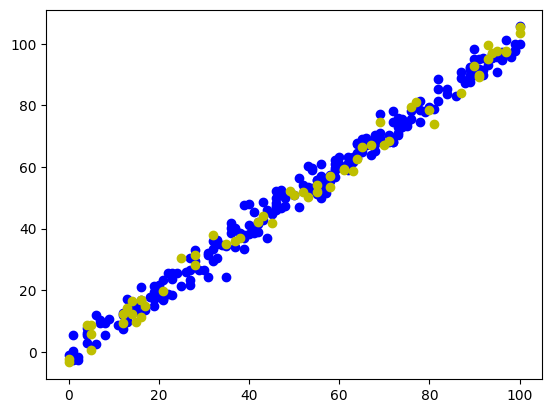

In [12]:
plt.scatter(x_train, y_train, c='b')
plt.scatter(x_test, y_test, c='y')
plt.show()

Model Building

In [13]:
x_train.shape

(240,)

In [46]:
tf.expand_dims(x_train, axis=-1).shape

TensorShape([240, 1])

In [71]:
# create model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(4, input_shape=(1,)),
    tf.keras.layers.Dense(1)
])

# compile model
model.compile(
    loss = tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics = ['mae', 'mse']
)

# train the model
epoch_number = 10
history = model.fit(tf.expand_dims(x_train, axis=-1), y_train, epochs=epoch_number)

Epoch 1/10


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 53.3912 - mae: 53.3912 - mse: 3698.3059  
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 45.9064 - mae: 45.9064 - mse: 2735.6169 
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 37.7284 - mae: 37.7284 - mse: 1870.0610 
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 27.4748 - mae: 27.4748 - mse: 1006.0489 
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14.5245 - mae: 14.5245 - mse: 299.8221 
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.2457 - mae: 4.2457 - mse: 26.9139 
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.4934 - mae: 4.4934 - mse: 30.2726 
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.0372 - mae: 3.0372 - mse: 14.2486 
Epoch 9/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4381 - mae: 2.4381 - mse: 9.6879  
Epoch 10/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.6804 - mae: 2.6804 - mse: 11.0808 


In [72]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 4)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (168.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 28 (116.00 B)

In [73]:
history.history

{'loss': [53.391151428222656,
  45.90636444091797,
  37.72837829589844,
  27.474761962890625,
  14.524534225463867,
  4.2457475662231445,
  4.4933624267578125,
  3.0372297763824463,
  2.4381020069122314,
  2.6803812980651855],
 'mae': [53.391151428222656,
  45.90636444091797,
  37.72837829589844,
  27.474761962890625,
  14.524534225463867,
  4.2457475662231445,
  4.4933624267578125,
  3.0372297763824463,
  2.4381020069122314,
  2.6803812980651855],
 'mse': [3698.305908203125,
  2735.616943359375,
  1870.06103515625,
  1006.0488891601562,
  299.8220520019531,
  26.913915634155273,
  30.272632598876953,
  14.248590469360352,
  9.687886238098145,
  11.080829620361328]}

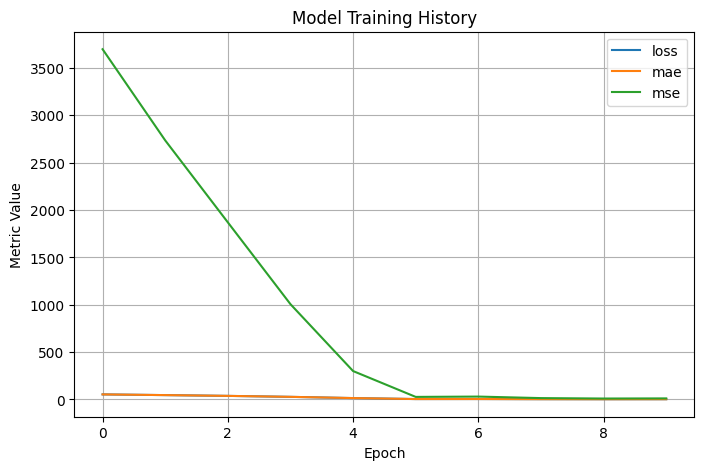

In [74]:
history_df = pd.DataFrame(history.history)

history_df.plot(figsize=(8,5))
plt.title('Model Training History')
plt.ylabel('Metric Value')
plt.xlabel('Epoch')
plt.grid(True)
plt.show()

In [75]:
y_pred = model.predict(x_test)
y_pred[:5]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([[88.81475 ],
       [75.17121 ],
       [92.71288 ],
       [ 5.979027],
       [89.78928 ]], dtype=float32)

In [76]:
y_test[:5]

,y
203,92.887723
266,79.503415
152,97.001484
9,8.746748
233,89.739520


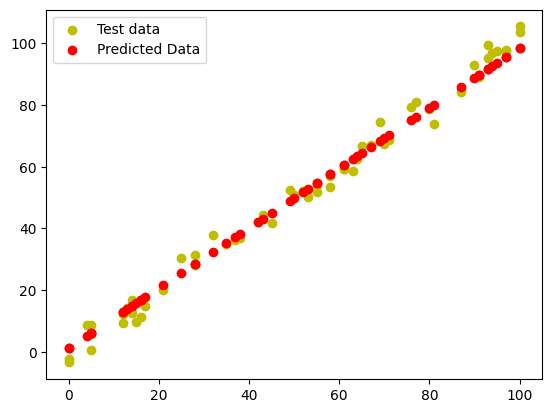

In [77]:
plt.scatter(x_test, y_test, c="y", label="Test data")
plt.scatter(x_test, y_pred, c="r", label="Predicted Data")
plt.legend()
plt.show()

Model Evaluation

In [78]:
# Using Evaluate Method
model.evaluate(x_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2.6422 - mae: 2.6422 - mse: 10.9387 


[2.64223575592041, 2.64223575592041, 10.938741683959961]

In [80]:
y_pred.shape

(60, 1)

In [100]:
# Initialize the metric object
mse_tracker = tf.keras.metrics.MeanSquaredError()

# Feed it your actuals and predictions
mse_tracker.update_state(y_test, tf.squeeze(y_pred))

# Extract the calculated tensor value
mse = mse_tracker.result()
mse

<tf.Tensor: shape=(), dtype=float32, numpy=10.938741683959961>

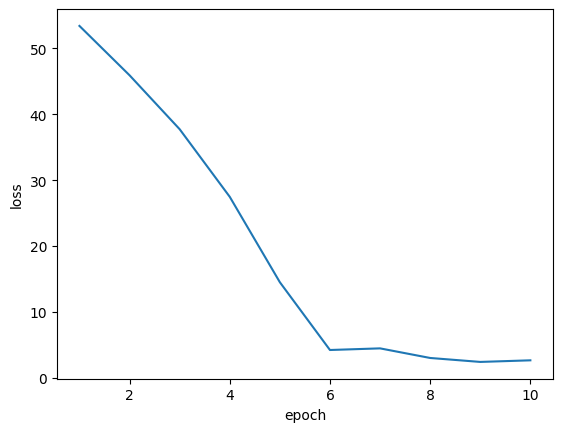

In [85]:
x_range = range(1, epoch_number+1)
loss = history.history['loss']
plt.plot(x_range, loss)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

Model Weights and Baises

In [93]:
for layer in model.layers:
  weights = layer.get_weights()[0]
  biases = layer.get_weights()[1]
  print(f"weights: {weights} \n biases: {biases}")

weights: [[ 0.21527992 -0.7508097   0.4914547  -0.31374523]] 
 biases: [-0.31573045 -0.43660504  0.44968292 -0.3836585 ]
weights: [[ 0.13163342]
 [-0.7268826 ]
 [ 0.5049128 ]
 [-0.48544943]] 
 biases: [0.4172404]
